NAME: PRIYANKA GADRE

INTERN ID: IN226049302

TASK 4: Fine -Tuning BERT on Kaggle Dataset

In [3]:
!pip install transformers scikit-learn seaborn -q

import numpy as np
import pandas as pd
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

# 🔥 SPEED FIX
df = df.sample(2000)

df.head()

,review,sentiment
32374,Please make me forget. Please. Please. This is...,negative
37723,Spike Lee has been in a decline since his earl...,negative
25655,Once upon a time Theresa Russell made a few ha...,negative
35234,"This show is quick-witted, colorful, dark yet ...",positive
30720,I could not agree less with the rating that wa...,positive


In [5]:
# Preprocessing

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = text.lower()
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [6]:
# Split Data

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean_review'], df['label'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

In [8]:
# Tokenization

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=128)

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [9]:
# Dataset Class

class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

In [10]:
# Model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [12]:
# DataLoaders + Optimizer

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

optimizer = AdamW(model.parameters(), lr=2e-5)

In [13]:
# Training Function

def train_model(model, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [14]:
# Evaluation Function

def evaluate(model, loader):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = accuracy_score(true, preds)
    prec = precision_score(true, preds)
    rec = recall_score(true, preds)
    f1 = f1_score(true, preds)

    return acc, prec, rec, f1, preds, true

In [15]:
# Training Loop

epochs = 1

for epoch in range(epochs):
    loss = train_model(model, train_loader)
    acc, prec, rec, f1, _, _ = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")


Epoch 1
Loss: 0.5332
Accuracy: 0.8750
Precision: 0.8824
Recall: 0.8738
F1 Score: 0.8780


In [16]:
# Final Evaluation

acc, prec, rec, f1, preds, true = evaluate(model, test_loader)

print("\nFinal Test Results:")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Final Test Results:
Accuracy: 0.815
Precision: 0.8421052631578947
Recall: 0.7843137254901961
F1 Score: 0.8121827411167513


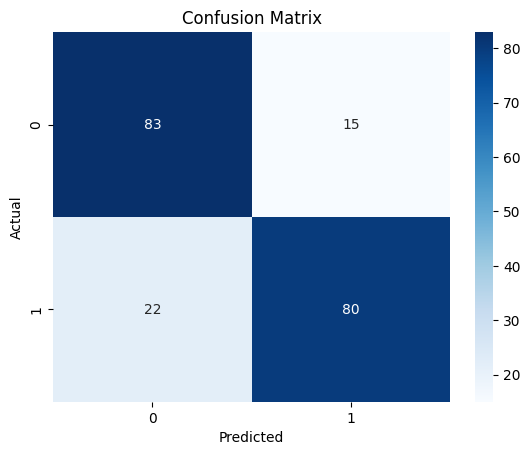

In [17]:
# Confusion Matrix

cm = confusion_matrix(true, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Model Used: DistilBERT

Reason:
Used DistilBERT instead of BERT for faster training with similar performance.

Observation:
Model achieved good accuracy with reduced computation time.